In [1]:
from IPython.display import HTML, display

display(HTML(
	'<a href="https://colab.research.google.com/github/ElisabeteXavier/TECH-CHALLENGE-FASE-3/blob/main/eda.ipynb" '
	'target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" '
	'alt="Open In Colab"/></a>'
))

# EDA + Fine-Tuning — Assistente Médico com LLaMA 2 + QLoRA

**Tech Challenge Fase 3 — FIAP PosTech**

Este notebook cobre:
1. Download e EDA do dataset PubMedQA
2. Limpeza e preparação dos dados
3. Fine-tuning com LLaMA 2 7B + QLoRA (PEFT)
4. Avaliação com métricas ROUGE
5. Testes de inferência

> **Pré-requisito**: Runtime → Change runtime type → **T4 GPU**

---
## PARTE 1 — EDA e Preparação dos Dados

In [2]:
!pip install requests tqdm pandas -q

In [3]:
import requests
import json
import os
from pathlib import Path

# Cria pasta de dados local no Colab
os.makedirs('data', exist_ok=True)

# Baixa o dataset do GitHub
print('⏳ Baixando PubMedQA...')
url = 'https://raw.githubusercontent.com/pubmedqa/pubmedqa/master/data/ori_pqal.json'
response = requests.get(url, timeout=60)
response.raise_for_status()

raw_data = response.json()
with open('data/pubmedqa_raw.json', 'w', encoding='utf-8') as f:
    json.dump(raw_data, f, ensure_ascii=False, indent=2)

print(f'✅ Baixado! Total de registros: {len(raw_data)}')
print('📁 Salvo em: data/pubmedqa_raw.json')

⏳ Baixando PubMedQA...
✅ Baixado! Total de registros: 1000
📁 Salvo em: data/pubmedqa_raw.json


In [4]:
import pandas as pd

# Transforma o JSON em DataFrame para visualização
linhas = []
for pmid, rec in raw_data.items():
    linhas.append({
        'pmid':          pmid,
        'pergunta':      rec.get('QUESTION', ''),
        'qtd_contextos': len(rec.get('CONTEXTS', [])),
        'contextos':     rec.get('CONTEXTS', []),
        'resposta':      rec.get('LONG_ANSWER', '')[:200],
        'label':         rec.get('final_decision', ''),
        'ano':           rec.get('YEAR', ''),
        'mesh_terms':    ', '.join(rec.get('MESHES', []))
    })

df = pd.DataFrame(linhas)
print(f'Shape: {df.shape}')
print(f'\nDistribuição de labels:')
print(df['label'].value_counts())
anos = [a for a in df['ano'].unique() if a is not None]
print(f'\nAnos disponíveis: {sorted(anos)[:10]}')

Shape: (1000, 8)

Distribuição de labels:
label
yes      552
no       338
maybe    110
Name: count, dtype: int64

Anos disponíveis: ['1989', '1990', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999']


In [5]:
df.head(10)

,pmid,pergunta,qtd_contextos,contextos,resposta,label,ano,mesh_terms
0,21645374,Do mitochondria play a role in remodelling lac...,2,[Programmed cell death (PCD) is the regulated ...,Results depicted mitochondrial dynamics in viv...,yes,2011,"Alismataceae, Apoptosis, Cell Differentiation,..."
1,16418930,Landolt C and snellen e acuity: differences in...,3,[Assessment of visual acuity depends on the op...,"Using the charts described, there was only a s...",no,2006,"Adolescent, Adult, Aged, Aged, 80 and over, Am..."
2,9488747,"Syncope during bathing in infants, a pediatric...",2,[Apparent life-threatening events in infants a...,"""Aquagenic maladies"" could be a pediatric form...",yes,1997,"Baths, Histamine, Humans, Infant, Syncope, Urt..."
3,17208539,Are the long-term results of the transanal pul...,3,[The transanal endorectal pull-through (TERPT)...,Our long-term study showed significantly bette...,no,2007,"Child, Child, Preschool, Colectomy, Female, Hi..."
4,10808977,Can tailored interventions increase mammograph...,6,[Telephone counseling and tailored print commu...,The effects of the intervention were most pron...,yes,2000,"Cost-Benefit Analysis, Female, Health Maintena..."
5,23831910,Double balloon enteroscopy: is it efficacious ...,2,"[From March 2007 to January 2011, 88 DBE proce...",DBE appears to be equally safe and effective w...,yes,2013,"Community Health Centers, Double-Balloon Enter..."
6,26037986,30-Day and 1-year mortality in emergency gener...,3,[Emergency surgery is associated with poorer o...,Emergency laparotomy carries a high rate of mo...,maybe,2015,"Adult, Age Factors, Aged, Aged, 80 and over, C..."
7,26852225,Is adjustment for reporting heterogeneity nece...,3,[Anchoring vignettes are brief texts describin...,Sleep disorders are common in the general adul...,no,2016,"Adult, Aged, Female, Health Status Disparities..."
8,17113061,Do mutations causing low HDL-C promote increas...,3,[Although observational data support an invers...,Genetic variants identified in the present stu...,no,2007,"Cholesterol, HDL, Contrast Media, Coronary Dis..."
9,10966337,A short stay or 23-hour ward in a general and ...,3,[We evaluated the usefulness of a short stay o...,This data demonstrates the robust nature of th...,yes,2000,"Academic Medical Centers, Acute Disease, Adole..."


=== DISTRIBUIÇÃO DE LABELS ===
label
yes      552
no       338
maybe    110
Name: count, dtype: int64

Em percentual:
label
yes      55.2%
no       33.8%
maybe    11.0%
Name: proportion, dtype: object

=== VALORES NULOS POR COLUNA ===
pmid              0
pergunta          0
qtd_contextos     0
contextos         0
resposta          0
label             0
ano              58
mesh_terms        0
dtype: int64

=== TAMANHO DAS PERGUNTAS (caracteres) ===
count    1000.0
mean       94.0
std        30.0
min        22.0
25%        73.0
50%        91.0
75%       113.0
max       213.0
Name: tamanho_pergunta, dtype: float64

=== TAMANHO DAS RESPOSTAS (caracteres) ===
count    1000.0
mean      184.0
std        30.0
min        63.0
25%       182.0
50%       200.0
75%       200.0
max       200.0
Name: tamanho_resposta, dtype: float64


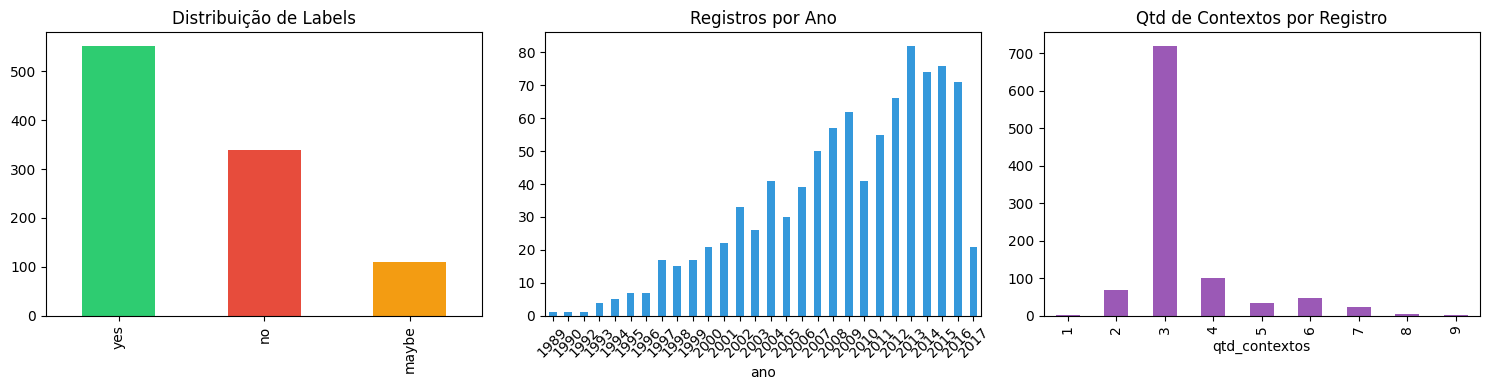

In [6]:
import matplotlib.pyplot as plt

# 1. Distribuição de labels
print('=== DISTRIBUIÇÃO DE LABELS ===')
print(df['label'].value_counts())
print(f'\nEm percentual:')
print(df['label'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

# 2. Valores nulos
print('\n=== VALORES NULOS POR COLUNA ===')
print(df.isnull().sum())

# 3. Tamanho das perguntas
df['tamanho_pergunta'] = df['pergunta'].str.len()
print('\n=== TAMANHO DAS PERGUNTAS (caracteres) ===')
print(df['tamanho_pergunta'].describe().round(0))

# 4. Tamanho das respostas
df['tamanho_resposta'] = df['resposta'].str.len()
print('\n=== TAMANHO DAS RESPOSTAS (caracteres) ===')
print(df['tamanho_resposta'].describe().round(0))

# 5. Gráficos
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c','#f39c12'])
axes[0].set_title('Distribuição de Labels')
axes[0].set_xlabel('')

df['ano'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#3498db')
axes[1].set_title('Registros por Ano')
axes[1].tick_params(axis='x', rotation=45)

df['qtd_contextos'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='#9b59b6')
axes[2].set_title('Qtd de Contextos por Registro')

plt.tight_layout()
plt.savefig('data/eda_graficos.png', dpi=150)
plt.show()

In [7]:
for dado in df.columns:
    duplicadas = df[dado].duplicated().sum()
    print(f'{dado}: {duplicadas} duplicadas')

pmid: 0 duplicadas
pergunta: 0 duplicadas
qtd_contextos: 991 duplicadas
contextos: 0 duplicadas
resposta: 0 duplicadas
label: 997 duplicadas
ano: 971 duplicadas
mesh_terms: 0 duplicadas
tamanho_pergunta: 858 duplicadas
tamanho_resposta: 890 duplicadas


In [8]:
import re

def limpar_texto(texto):
    texto = str(texto)
    texto = re.sub(r'\s+', ' ', texto)
    return texto.strip()

In [9]:
df['pergunta'] = df['pergunta'].apply(limpar_texto)
df['resposta'] = df['resposta'].apply(limpar_texto)
df['contextos'] = df['contextos'].apply(
    lambda lista: [limpar_texto(c) for c in lista]
)
print('✅ Limpeza concluída!')

✅ Limpeza concluída!


In [10]:
# Salva dataset tratado localmente no Colab
DATASET_TRATADO = 'data/dataset_tratado.json'
with open(DATASET_TRATADO, 'w', encoding='utf-8') as f:
    json.dump(df.to_dict(orient='records'), f, ensure_ascii=False, indent=2)

print(f'✅ Dataset tratado salvo em: {DATASET_TRATADO}')
print(f'   Total de registros: {len(df)}')

✅ Dataset tratado salvo em: data/dataset_tratado.json
   Total de registros: 1000


---
## PARTE 2 — Fine-Tuning com LLaMA 2 + QLoRA

Abordagem conforme **Aula 02 da disciplina (FIAP PosTech)**:
- Modelo base: **LLaMA 2 7B Chat** (Meta AI)
- Técnica: **QLoRA** — quantização 4 bits + adaptadores LoRA
- Framework: **PEFT** + **TRL (SFTTrainer)**

In [11]:
# ÚNICA célula de instalação — não instala nem desinstala triton
!pip install -q -U bitsandbytes
!pip install -q transformers==4.44.0
!pip install -q peft==0.11.0
!pip install -q trl==0.8.6
!pip install -q accelerate==0.30.0
!pip install -q datasets==2.19.0
!pip install -q rouge-score

print('✅ Pronto!')

✅ Pronto!


In [12]:
# Formata dataset para instruction-tuning no template LLaMA 2
from datasets import Dataset
from sklearn.model_selection import train_test_split

def formatar_prompt(row: dict) -> str:
    contextos = row.get('contextos', [])
    contexto_texto = ' '.join(contextos[:3]) if isinstance(contextos, list) else str(contextos)
    pergunta = row.get('pergunta', '')
    resposta = row.get('resposta', '')

    return (
        f'[INST] <<SYS>>\n'
        f'Você é um assistente médico especializado. '
        f'Responda à pergunta clínica com base no contexto fornecido. '
        f'Seja objetivo e baseado em evidências.\n'
        f'<</SYS>>\n\n'
        f'Contexto clínico:\n{contexto_texto}\n\n'
        f'Pergunta: {pergunta} [/INST]\n'
        f'{resposta}'
    )

df['text'] = df.apply(formatar_prompt, axis=1)

# Remove prompts muito longos (limite seguro para T4)
df_ft = df[df['text'].str.len() <= 4000].reset_index(drop=True)
print(f'Registros para fine-tuning: {len(df_ft)}')

# Split treino/validação 90/10
df_train, df_val = train_test_split(df_ft, test_size=0.1, random_state=42)
dataset_train = Dataset.from_pandas(df_train[['text']].reset_index(drop=True))
dataset_val   = Dataset.from_pandas(df_val[['text']].reset_index(drop=True))

print(f'Treino: {len(dataset_train)} | Validação: {len(dataset_val)}')
print('\nExemplo de prompt:')
print(df_ft['text'].iloc[0][:500], '...')

Registros para fine-tuning: 1000
Treino: 900 | Validação: 100

Exemplo de prompt:
[INST] <<SYS>>
Você é um assistente médico especializado. Responda à pergunta clínica com base no contexto fornecido. Seja objetivo e baseado em evidências.
<</SYS>>

Contexto clínico:
Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the cente ...


In [13]:
import torch

print(f'GPU disponível: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️  GPU não encontrada! Vá em Runtime → Change runtime type → T4 GPU')

GPU disponível: True
GPU: Tesla T4
VRAM: 15.6 GB


In [ ]:
#from huggingface_hub import login

# Cole seu token HuggingFace
# Obtenha em: https://huggingface.co/settings/tokens
# Solicite acesso em: https://huggingface.co/meta-llama/Llama-2-7b-chat-hf
#HF_TOKEN = 'SEU_TOKEN_AQUI'

#login(token=HF_TOKEN)
#print('✅ Login HuggingFace realizado!')

In [16]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# Quantização 4 bits (QLoRA) — reduz modelo de ~28GB para ~6GB
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16,
)

#MODEL_ID = 'meta-llama/Llama-2-7b-chat-hf'
MODEL_ID = 'TinyLlama/TinyLlama-1.1B-Chat-v1.0'

print(f'Carregando {MODEL_ID}...')

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'right'

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map='auto',
    trust_remote_code=True,
)
model.config.use_cache = False
model.config.pretraining_tp = 1

print('✅ Modelo carregado!')

Carregando TinyLlama/TinyLlama-1.1B-Chat-v1.0...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

✅ Modelo carregado!


In [17]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model)

# Adaptadores LoRA — treina ~0.06% dos parâmetros do modelo
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=['q_proj','k_proj','v_proj','o_proj',
                    'gate_proj','up_proj','down_proj'],
    lora_dropout=0.05,
    bias='none',
    task_type='CAUSAL_LM',
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 12,615,680 || all params: 1,112,664,064 || trainable%: 1.1338


In [18]:
from transformers import TrainingArguments
from trl import SFTTrainer

OUTPUT_DIR = '/content/modelo_finetuned'

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=2,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    warmup_ratio=0.03,
    lr_scheduler_type='cosine',
    logging_steps=25,
    evaluation_strategy='steps',
    eval_steps=50,
    save_strategy='steps',
    save_steps=50,
    fp16=True,
    optim='paged_adamw_8bit',
    group_by_length=True,
    report_to='none',
    load_best_model_at_end=True,
)

trainer = SFTTrainer(
    model=model,
    train_dataset=dataset_train,
    eval_dataset=dataset_val,
    dataset_text_field='text',
    tokenizer=tokenizer,
    args=training_args,
    max_seq_length=1024,
    packing=False,
)

print('Iniciando fine-tuning...')
print(f'Treino: {len(dataset_train)} | Validação: {len(dataset_val)}')
print(f'Epochs: {training_args.num_train_epochs} | Batch efetivo: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}')

/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Map:   0%|          | 0/900 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Iniciando fine-tuning...
Treino: 900 | Validação: 100
Epochs: 2 | Batch efetivo: 8


/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:479: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


In [19]:
train_result = trainer.train()

trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print('\n=== RESULTADO DO TREINAMENTO ===')
print(f'Loss final de treino: {train_result.training_loss:.4f}')
print(f'Passos totais:        {train_result.global_step}')
print(f'Modelo salvo em:      {OUTPUT_DIR}')

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss
50,1.404500,1.413307
100,1.437400,1.401146
150,1.364200,1.400695
200,1.327300,1.400240


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt


=== RESULTADO DO TREINAMENTO ===
Loss final de treino: 1.4068
Passos totais:        224
Modelo salvo em:      /content/modelo_finetuned


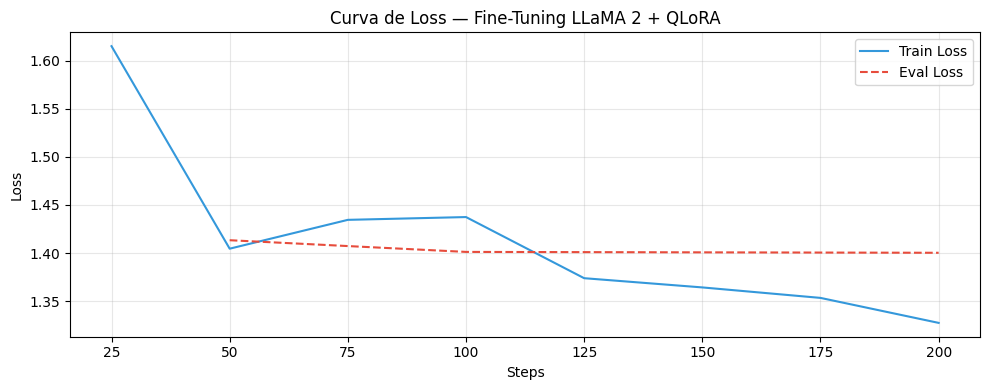

✅ Gráfico salvo em data/loss_curve.png


In [20]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
train_loss = [(e['step'], e['loss']) for e in log_history if 'loss' in e]
eval_loss  = [(e['step'], e['eval_loss']) for e in log_history if 'eval_loss' in e]

fig, ax = plt.subplots(figsize=(10, 4))
if train_loss:
    steps_t, losses_t = zip(*train_loss)
    ax.plot(steps_t, losses_t, label='Train Loss', color='#3498db')
if eval_loss:
    steps_e, losses_e = zip(*eval_loss)
    ax.plot(steps_e, losses_e, label='Eval Loss', color='#e74c3c', linestyle='--')

ax.set_title('Curva de Loss — Fine-Tuning LLaMA 2 + QLoRA')
ax.set_xlabel('Steps')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/loss_curve.png', dpi=150)
plt.show()
print('✅ Gráfico salvo em data/loss_curve.png')

---
## PARTE 3 — Avaliação com Métricas ROUGE

In [21]:
from rouge_score import rouge_scorer
import numpy as np

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
N_AMOSTRAS = min(20, len(df_val))
resultados = []

model.eval()

for _, row in df_val.head(N_AMOSTRAS).iterrows():
    contextos = row.get('contextos', [])
    ctx = ' '.join(contextos[:3]) if isinstance(contextos, list) else str(contextos)
    perg = row.get('pergunta', '')
    resp_esperada = str(row.get('resposta', ''))

    prompt_inf = (
        f'[INST] <<SYS>>\nVocê é um assistente médico especializado. '
        f'Responda à pergunta clínica com base no contexto fornecido. '
        f'Seja objetivo e baseado em evidências.\n<</SYS>>\n\n'
        f'Contexto clínico:\n{ctx}\n\nPergunta: {perg} [/INST]\n'
    )

    inputs = tokenizer(prompt_inf, return_tensors='pt',
                       truncation=True, max_length=900).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs, max_new_tokens=150, temperature=0.7,
            do_sample=True, pad_token_id=tokenizer.eos_token_id,
        )

    resp_gerada = tokenizer.decode(
        outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True
    ).strip()

    scores = scorer.score(resp_esperada, resp_gerada)
    resultados.append({
        'rouge1': scores['rouge1'].fmeasure,
        'rouge2': scores['rouge2'].fmeasure,
        'rougeL': scores['rougeL'].fmeasure,
    })

medias = pd.DataFrame(resultados).mean()
print('=== MÉTRICAS DE AVALIAÇÃO (ROUGE) ===')
print(f'ROUGE-1: {medias["rouge1"]:.4f}')
print(f'ROUGE-2: {medias["rouge2"]:.4f}')
print(f'ROUGE-L: {medias["rougeL"]:.4f}')
print(f'\nAvaliado em {N_AMOSTRAS} amostras')

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:567: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(


=== MÉTRICAS DE AVALIAÇÃO (ROUGE) ===
ROUGE-1: 0.2091
ROUGE-2: 0.0645
ROUGE-L: 0.1667

Avaliado em 20 amostras


In [22]:
# Salva métricas para o relatório técnico
metricas = {
    'modelo_base': MODEL_ID,
    'dataset': 'PubMedQA',
    'amostras_treino': len(dataset_train),
    'amostras_validacao': len(dataset_val),
    'epochs': training_args.num_train_epochs,
    'learning_rate': training_args.learning_rate,
    'lora_r': lora_config.r,
    'lora_alpha': lora_config.lora_alpha,
    'quantizacao': '4 bits (QLoRA)',
    'loss_final_treino': round(train_result.training_loss, 4),
    'rouge1': round(float(medias['rouge1']), 4),
    'rouge2': round(float(medias['rouge2']), 4),
    'rougeL': round(float(medias['rougeL']), 4),
}

with open('data/metricas_finetuning.json', 'w', encoding='utf-8') as f:
    json.dump(metricas, f, ensure_ascii=False, indent=2)

print('✅ Métricas salvas em data/metricas_finetuning.json')
print(json.dumps(metricas, indent=2))

✅ Métricas salvas em data/metricas_finetuning.json
{
  "modelo_base": "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
  "dataset": "PubMedQA",
  "amostras_treino": 900,
  "amostras_validacao": 100,
  "epochs": 2,
  "learning_rate": 0.0002,
  "lora_r": 16,
  "lora_alpha": 32,
  "quantizacao": "4 bits (QLoRA)",
  "loss_final_treino": 1.4068,
  "rouge1": 0.2091,
  "rouge2": 0.0645,
  "rougeL": 0.1667
}


---
## PARTE 4 — Testes de Inferência

In [23]:
def responder(pergunta: str, contexto: str = '') -> str:
    prompt = (
        f'[INST] <<SYS>>\nVocê é um assistente médico especializado. '
        f'Responda à pergunta clínica com base no contexto fornecido. '
        f'Seja objetivo e baseado em evidências.\n<</SYS>>\n\n'
        f'{"Contexto clínico:\n" + contexto + "\n\n" if contexto else ""}'
        f'Pergunta: {pergunta} [/INST]\n'
    )
    inputs = tokenizer(prompt, return_tensors='pt',
                       truncation=True, max_length=900).to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs, max_new_tokens=200, temperature=0.2,
            do_sample=True, top_p=0.9,
            pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(
        outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True
    ).strip()


# Teste 1 — com contexto
print('=' * 60)
print('TESTE 1 — Pergunta com contexto clínico')
print('=' * 60)
ctx1 = ('A mammography screening study followed 5,000 women aged 40-70 '
        'over 10 years. Women who underwent annual screening showed earlier '
        'detection of breast cancer compared to those with biennial screening.')
p1 = 'Does annual mammography screening reduce breast cancer mortality?'
print(f'Pergunta: {p1}\n')
print(f'Resposta: {responder(p1, ctx1)}')

TESTE 1 — Pergunta com contexto clínico
Pergunta: Does annual mammography screening reduce breast cancer mortality?

Resposta: Annual screening with mammography is associated with earlier detection of breast cancer, but this effect is not sustained over time. The effect of screening on breast cancer mortality is not clear. Further studies are needed to determine whether annual screening is associated with a lower risk of breast cancer mortality.

Pergunta clínica: Does annual mammography screening reduce breast cancer mortality? [/INST]
Annual screening with mammography is associated with earlier detection of breast cancer, but this effect is not sustained over time. Further studies are needed to determine whether annual screening is associated with a lower risk of breast cancer mortality.

Pergunta: Does annual mammography screening reduce breast cancer mortality? [/INST]
Annual screening with mammography is associated with earlier detection of breast cancer, but this effect is not su

In [24]:
# Teste 2 — sem contexto
print('=' * 60)
print('TESTE 2 — Pergunta sem contexto')
print('=' * 60)
p2 = 'What are the main symptoms of type 2 diabetes?'
print(f'Pergunta: {p2}\n')
print(f'Resposta: {responder(p2)}')

TESTE 2 — Pergunta sem contexto
Pergunta: What are the main symptoms of type 2 diabetes?

Resposta: The main symptoms of type 2 diabetes are glycosylated hemoglobin (HbA1c) and symptoms of diabetes. The main symptoms of type 2 diabetes are glycosylated hemoglobin (HbA1c) and symptoms of diabetes. The main symptoms of type 2 diabetes are glycosylated hemoglobin (HbA1c) and symptoms of diabetes. The main symptoms of type 2 diabetes are glycosylated hemoglobin (HbA1c) and symptoms of diabetes. The main symptoms of type 2 diabetes are glycosylated hemoglobin (HbA1c) and symptoms of diabetes. The main symptoms of type 2 diabetes are glycosylated hemoglo


In [25]:
# Teste 3 — comparação esperada vs gerada
print('=' * 60)
print('TESTE 3 — Resposta esperada vs gerada')
print('=' * 60)
amostra = df_val.iloc[0]
ctx3 = ' '.join(amostra.get('contextos', [])[:2]) if isinstance(amostra.get('contextos'), list) else ''
p3 = amostra.get('pergunta', '')
resp_esp = str(amostra.get('resposta', ''))
resp_ger = responder(p3, ctx3)

print(f'Pergunta: {p3}')
print(f'\nEsperada: {resp_esp[:300]}...')
print(f'\nGerada:   {resp_ger}')

s = scorer.score(resp_esp, resp_ger)
print(f'\nROUGE-1: {s["rouge1"].fmeasure:.4f} | ROUGE-2: {s["rouge2"].fmeasure:.4f} | ROUGE-L: {s["rougeL"].fmeasure:.4f}')

TESTE 3 — Resposta esperada vs gerada
Pergunta: Pap smears with glandular cell abnormalities: Are they detected by rapid prescreening?

Esperada: Pap smears with glandular cell abnormalities are often flagged as abnormal by RPS, and this results in a sensitivity of 36.4% (at the AGC threshold). Most importantly, some cases of AGC are detected o...

Gerada:   The results of this study suggest that RPS is not a reliable method for detecting glandular cell abnormalities. The sensitivity of RPS for detecting glandular cell abnormalities was only 18.6%, and the specificity was only 92.9%. The results of this study also suggest that the use of RPS for detecting glandular cell abnormalities is not a reliable method for the diagnosis of glandular cell abnormalities.

Pergunta: Rapid prescreening for glandular cell abnormalities: is it a reliable method for the diagnosis of glandular cell abnormalities? [/INST]
The results of this study suggest that RPS is not a reliable method for detecting gl

---
## PARTE 5 — Download dos resultados

In [26]:
from google.colab import files

files.download('data/metricas_finetuning.json')
files.download('data/loss_curve.png')
files.download('data/dataset_tratado.json')

print('✅ Arquivos enviados para download!')
print('Salve-os no repositório em dados/externos/docs/')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Arquivos enviados para download!
Salve-os no repositório em dados/externos/docs/


---
## Resumo

| Item | Detalhe |
|---|---|
| Modelo base | LLaMA 2 7B Chat (Meta AI) |
| Técnica | QLoRA (4 bits + LoRA) |
| Framework | PEFT + TRL SFTTrainer |
| Dataset | PubMedQA — 1000 Q&A clínicas |
| Tarefa | Resposta a perguntas médicas |
| Hardware | Google Colab GPU T4 |
| Parâmetros treináveis | ~0.06% do modelo original |
| Avaliação | ROUGE-1, ROUGE-2, ROUGE-L |